### General Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os, torch, datetime, time
import numpy as np
sys.path.append("..")
import rfi_ml_bmxM
import matplotlib.pyplot as plt

In [2]:
print(f"Is CUDA supported by this system?{torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

Is CUDA supported by this system?True
CUDA version: 12.1


### Loading Data

In [4]:
train = np.load('D:/bmxdata/train_data/201107_002700/5_0000.npy')
test = np.load('D:/bmxdata/eval_data/201107_172400/1_0000.npy')

In [5]:
test.shape

(1022, 2048)

In [6]:
np.std(train[86])

0.105304286

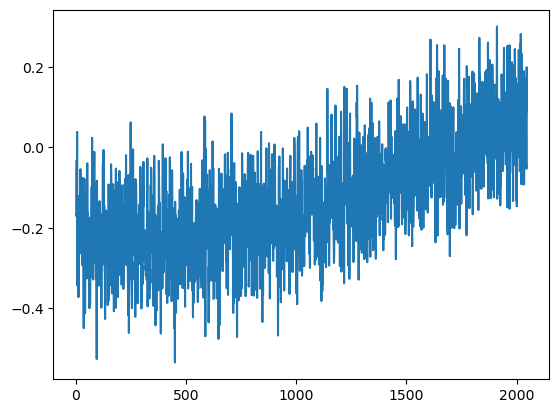

In [18]:
plt.plot(train[400])

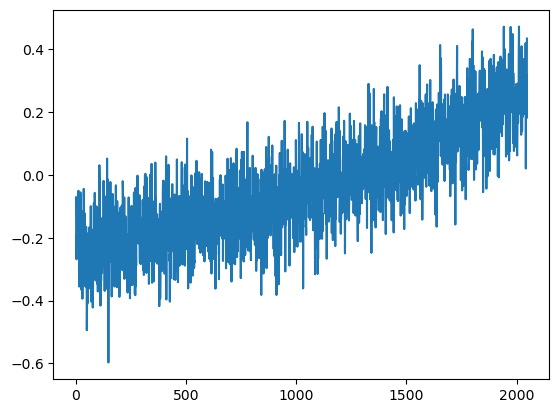

In [28]:
plt.plot(train[165])

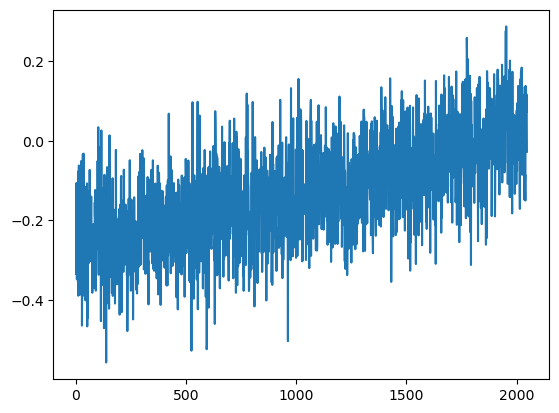

In [47]:
x = np.linspace(0, 2048, 2048)
plt.plot(train[100] + (0.0001*x-0.1))

TypeError: float() argument must be a string or a real number, not 'numpy.ufunc'

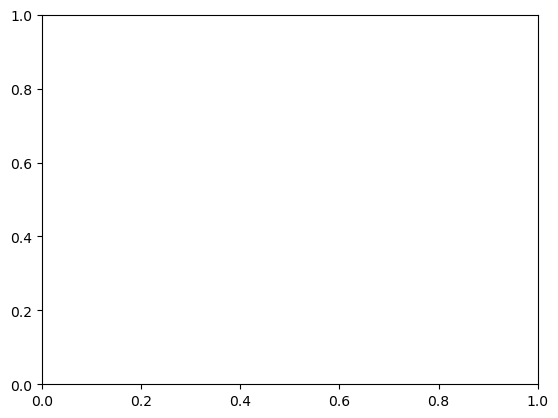

In [51]:
u = np.linspace(0, 2048, 100)
plt.plot(np.sin(x))

(array([  5.,   0.,   4.,  13.,  34.,  56., 104., 151., 227., 255., 273.,
        271., 228., 176., 108.,  72.,  41.,  18.,   9.,   3.]),
 array([-0.49937937, -0.46484089, -0.43030241, -0.3957639 , -0.36122543,
        -0.32668695, -0.29214847, -0.25760999, -0.2230715 , -0.18853302,
        -0.15399453, -0.11945605, -0.08491758, -0.05037909, -0.01584061,
         0.01869788,  0.05323636,  0.08777484,  0.12231333,  0.15685181,
         0.19139029]),
 <BarContainer object of 20 artists>)

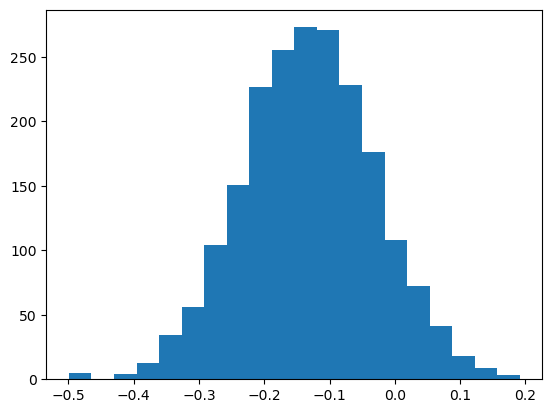

In [22]:
plt.hist(train[100], bins=20)

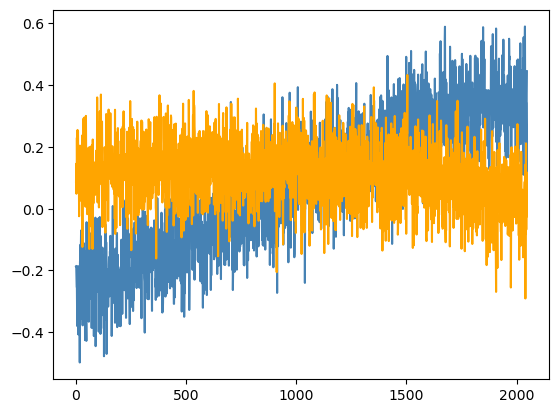

In [8]:
plt.plot(train[2], color='steelblue')
plt.plot(test[12], color='orange')
plt.show()

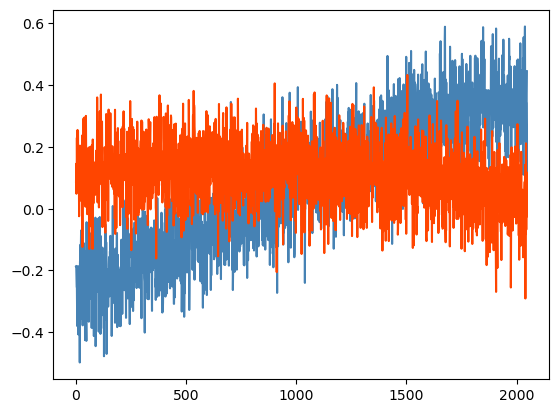

In [74]:
plt.plot(train[2], color='steelblue')
plt.plot(test[12], color='orangered')
plt.show()

In [3]:
# Downloading from main drive (Windows)

train_dir='C:/MLdatasets/ben_data/train_data' #BMX data should already be chunked into 1024 sets
eval_dir='C:/MLdatasets/ben_data/eval_data'

# Downloading from external drive
#train_dir='D:/MLdatasets/bmxdata/train_data'
#eval_dir='C:/MLdatasets/bmxdata/eval_data'


freq = '0000' #setting frequency channel

In [5]:
Nepochs = 30
Np = 2**11 #2k
hidden_dim = 2**10
z_dim = 16
Nfft = Np // 2 + 1

start_time = time.time()

b = rfi_ml_bmxM.BMXLoader(Np=Np, freq=freq)
train_data = b.loadData(data_dir=train_dir, test=False)
eval_data = b.loadData(data_dir=eval_dir, test=False)
train_data, eval_data = b.normalizeData(train_data, eval_data)

Data dir: C:/MLdatasets/ben_data/train_data/**/*_0000.npy
Data Loaded!
Size:  (118552, 2048)
Data dir: C:/MLdatasets/ben_data/eval_data/**/*_0000.npy
Data Loaded!
Size:  (89936, 2048)
Train data mean:  2.214976970311273e-17
Eval data mean:  2.0194637833732208e-16
RMS normalization factor:  0.055328948869969016


In [10]:
len(test_array)

NameError: name 'test_array' is not defined

### Training Parameters

In [9]:
n = rfi_ml_bmxM.RFIDetect(Np, Nepochs = Nepochs, z_dim = z_dim, hidden_dim = hidden_dim)

In [7]:
n.train(train_data)
del train_data

[  0/30][  0/3704]	Loss: 0.0032266476
[  0/30][100/3704]	Loss: 0.0016392679
[  0/30][200/3704]	Loss: 0.0011901916
[  0/30][300/3704]	Loss: 0.0007368731
[  0/30][400/3704]	Loss: 0.0012778350
[  0/30][500/3704]	Loss: 0.0014270011
[  0/30][600/3704]	Loss: 0.0013386984
[  0/30][700/3704]	Loss: 0.0011830407
[  0/30][800/3704]	Loss: 0.0010626068
[  0/30][900/3704]	Loss: 0.0010722588
[  0/30][1000/3704]	Loss: 0.0014717168
[  0/30][1100/3704]	Loss: 0.0010662748
[  0/30][1200/3704]	Loss: 0.0014000151
[  0/30][1300/3704]	Loss: 0.0012277381
[  0/30][1400/3704]	Loss: 0.0011894020
[  0/30][1500/3704]	Loss: 0.0011279869
[  0/30][1600/3704]	Loss: 0.0009121757
[  0/30][1700/3704]	Loss: 0.0013609694
[  0/30][1800/3704]	Loss: 0.0009161487
[  0/30][1900/3704]	Loss: 0.0012032005
[  0/30][2000/3704]	Loss: 0.0012026357
[  0/30][2100/3704]	Loss: 0.0014530201
[  0/30][2200/3704]	Loss: 0.0016493541
[  0/30][2300/3704]	Loss: 0.0011378461
[  0/30][2400/3704]	Loss: 0.0011376685
[  0/30][2500/3704]	Loss: 0.0008400

[ 11/30][1656/3704]	Loss: 0.0013217189
[ 11/30][1756/3704]	Loss: 0.0009408962
[ 11/30][1856/3704]	Loss: 0.0010348731
[ 11/30][1956/3704]	Loss: 0.0010476040
[ 11/30][2056/3704]	Loss: 0.0009228186
[ 11/30][2156/3704]	Loss: 0.0010080608
[ 11/30][2256/3704]	Loss: 0.0007979378
[ 11/30][2356/3704]	Loss: 0.0009981894
[ 11/30][2456/3704]	Loss: 0.0009706012
[ 11/30][2556/3704]	Loss: 0.0006645682
[ 11/30][2656/3704]	Loss: 0.0010016547
[ 11/30][2756/3704]	Loss: 0.0007390735
[ 11/30][2856/3704]	Loss: 0.0007844385
[ 11/30][2956/3704]	Loss: 0.0011013391
[ 11/30][3056/3704]	Loss: 0.0011128294
[ 11/30][3156/3704]	Loss: 0.0007522118
[ 11/30][3256/3704]	Loss: 0.0011620696
[ 11/30][3356/3704]	Loss: 0.0010844279
[ 11/30][3456/3704]	Loss: 0.0009335791
[ 11/30][3556/3704]	Loss: 0.0008021635
[ 11/30][3656/3704]	Loss: 0.0011287250
[ 12/30][ 52/3704]	Loss: 0.0009986354
[ 12/30][152/3704]	Loss: 0.0008727100
[ 12/30][252/3704]	Loss: 0.0010665593
[ 12/30][352/3704]	Loss: 0.0010765028
[ 12/30][452/3704]	Loss: 0.00

[ 17/30][632/3704]	Loss: 0.0009488922
[ 17/30][732/3704]	Loss: 0.0008755439
[ 17/30][832/3704]	Loss: 0.0009020275
[ 17/30][932/3704]	Loss: 0.0009985992
[ 17/30][1032/3704]	Loss: 0.0008165031
[ 17/30][1132/3704]	Loss: 0.0008871303
[ 17/30][1232/3704]	Loss: 0.0008807917
[ 17/30][1332/3704]	Loss: 0.0009357888
[ 17/30][1432/3704]	Loss: 0.0008707149
[ 17/30][1532/3704]	Loss: 0.0009312507
[ 17/30][1632/3704]	Loss: 0.0007625677
[ 17/30][1732/3704]	Loss: 0.0007041773
[ 17/30][1832/3704]	Loss: 0.0010206320
[ 17/30][1932/3704]	Loss: 0.0008231656
[ 17/30][2032/3704]	Loss: 0.0009768845
[ 17/30][2132/3704]	Loss: 0.0009444038
[ 17/30][2232/3704]	Loss: 0.0008423355
[ 17/30][2332/3704]	Loss: 0.0008164585
[ 17/30][2432/3704]	Loss: 0.0007848091
[ 17/30][2532/3704]	Loss: 0.0007742945
[ 17/30][2632/3704]	Loss: 0.0008399109
[ 17/30][2732/3704]	Loss: 0.0009040851
[ 17/30][2832/3704]	Loss: 0.0007501000
[ 17/30][2932/3704]	Loss: 0.0007699095
[ 17/30][3032/3704]	Loss: 0.0008788370
[ 17/30][3132/3704]	Loss: 0.0

[ 22/30][3312/3704]	Loss: 0.0009305339
[ 22/30][3412/3704]	Loss: 0.0009388770
[ 22/30][3512/3704]	Loss: 0.0008135762
[ 22/30][3612/3704]	Loss: 0.0008622705
[ 23/30][  8/3704]	Loss: 0.0007759134
[ 23/30][108/3704]	Loss: 0.0008023611
[ 23/30][208/3704]	Loss: 0.0006822393
[ 23/30][308/3704]	Loss: 0.0009524950
[ 23/30][408/3704]	Loss: 0.0009901620
[ 23/30][508/3704]	Loss: 0.0011691600
[ 23/30][608/3704]	Loss: 0.0007302665
[ 23/30][708/3704]	Loss: 0.0010177633
[ 23/30][808/3704]	Loss: 0.0011017127
[ 23/30][908/3704]	Loss: 0.0008487932
[ 23/30][1008/3704]	Loss: 0.0009259465
[ 23/30][1108/3704]	Loss: 0.0007521538
[ 23/30][1208/3704]	Loss: 0.0008502393
[ 23/30][1308/3704]	Loss: 0.0007144363
[ 23/30][1408/3704]	Loss: 0.0007971431
[ 23/30][1508/3704]	Loss: 0.0007329978
[ 23/30][1608/3704]	Loss: 0.0007450830
[ 23/30][1708/3704]	Loss: 0.0009728254
[ 23/30][1808/3704]	Loss: 0.0011403246
[ 23/30][1908/3704]	Loss: 0.0008115887
[ 23/30][2008/3704]	Loss: 0.0010074726
[ 23/30][2108/3704]	Loss: 0.0006601

[ 28/30][2288/3704]	Loss: 0.0008406959
[ 28/30][2388/3704]	Loss: 0.0010133712
[ 28/30][2488/3704]	Loss: 0.0008416968
[ 28/30][2588/3704]	Loss: 0.0010374152
[ 28/30][2688/3704]	Loss: 0.0008188323
[ 28/30][2788/3704]	Loss: 0.0009955462
[ 28/30][2888/3704]	Loss: 0.0006471197
[ 28/30][2988/3704]	Loss: 0.0006365239
[ 28/30][3088/3704]	Loss: 0.0008489238
[ 28/30][3188/3704]	Loss: 0.0009150091
[ 28/30][3288/3704]	Loss: 0.0010482401
[ 28/30][3388/3704]	Loss: 0.0007661519
[ 28/30][3488/3704]	Loss: 0.0005866800
[ 28/30][3588/3704]	Loss: 0.0010024542
[ 28/30][3688/3704]	Loss: 0.0009817907
[ 29/30][ 84/3704]	Loss: 0.0006679685
[ 29/30][184/3704]	Loss: 0.0008751776
[ 29/30][284/3704]	Loss: 0.0008707471
[ 29/30][384/3704]	Loss: 0.0008816547
[ 29/30][484/3704]	Loss: 0.0008936792
[ 29/30][584/3704]	Loss: 0.0010395136
[ 29/30][684/3704]	Loss: 0.0006760212
[ 29/30][784/3704]	Loss: 0.0009414683
[ 29/30][884/3704]	Loss: 0.0008330989
[ 29/30][984/3704]	Loss: 0.0007271161
[ 29/30][1084/3704]	Loss: 0.0006828

In [9]:
start_test = time.time()
rfi_recov = n.evaluate(eval_data)
end_test = time.time()

Epochs:  30
N tests:  89936
Length of timestream:  2048
Input Timestream RMS:  [0.01387627 0.01158426 0.01277735 ... 0.03350664 0.02007465 0.05432052]
Avg RMS for all tests:  0.033699054 



Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_0.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_1.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_2.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_3.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_4.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_5.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_6.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_7.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_8.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_9.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_10.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_11.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_12.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_13.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_14.png
Saving file...rfi_ml/2024-06-27_08-56-39_overplot_test_15.png
Saving file...rfi_

KeyboardInterrupt: 

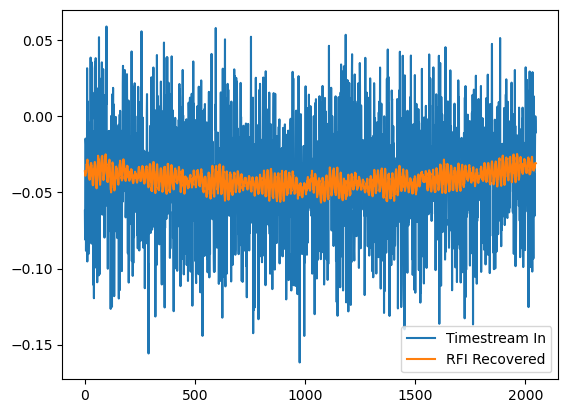

Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_264.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_265.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_266.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_267.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_268.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_269.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_270.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_271.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_272.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_273.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_274.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_275.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_276.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_277.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_278.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_

Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_396.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_397.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_398.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_399.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_400.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_401.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_402.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_403.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_404.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_405.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_406.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_407.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_408.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_409.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_410.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_

Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_528.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_529.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_530.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_531.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_532.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_533.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_534.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_535.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_536.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_537.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_538.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_539.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_540.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_541.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_542.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_

Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_659.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_660.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_661.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_662.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_663.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_664.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_665.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_666.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_667.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_668.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_669.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_670.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_671.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_672.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_673.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_

Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_791.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_792.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_793.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_794.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_795.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_796.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_797.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_798.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_799.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_800.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_801.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_802.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_803.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_804.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_805.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_

Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_922.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_923.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_924.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_925.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_926.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_927.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_928.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_929.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_930.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_931.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_932.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_933.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_934.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_935.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_936.png
Saving file...rfi_ml/2022-08-15_11-50-35_overplot_test_

In [10]:
n.plot_eval(rfi_recov, eval_data)

In [7]:
print("Runtime: ", time.time()-start_time)
print("Evaltime: ", end_test-start_test)

Runtime:  1000.8468551635742
Evaltime:  0.05579710006713867
